# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [25]:
def convert_bd2df_ravenpro(df: pd.DataFrame):
    """
    Converts a dataframe to the format used by RavenPro
    """

    ravenpro_df = df.copy()

    ravenpro_df.rename(columns={
        "start_time": "Begin Time (s)",
        "end_time": "End Time (s)",
        "low_freq": "Low Freq (Hz)",
        "high_freq": "High Freq (Hz)",
        "event": "Annotation",
        "freq_group":"Manually-Verified Phonic Group",
        'snr_nist_quick_dB':'SNR NIST Quick (dB)',
        'delta_time_s':'Delta Time (s)'
    }, inplace=True)

    ravenpro_df["Selection"] = np.arange(0, df.shape[0]).astype('int') + 1
    ravenpro_df["View"] = "Waveform 1"
    ravenpro_df["Channel"] = "1"

    return ravenpro_df

In [6]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [8]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20250113__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [9]:
def return_confusion_matrix_from_comparing_two_detectors(human_df, machine_df):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]

        machine_det_start_in_human_det_bounds = ((machine_det['start_time']>=human_det['start_time'])&(machine_det['start_time']<=human_det['end_time']))
        machine_det_end_in_human_det_bounds = ((machine_det['end_time']>=human_det['start_time'])&(machine_det['end_time']<=human_det['end_time']))
        human_det_start_in_machine_det_bounds = ((human_det['start_time']>=machine_det['start_time'])&(human_det['start_time']<=machine_det['end_time']))
        human_det_end_in_machine_det_bounds = ((human_det['end_time']>=machine_det['start_time'])&(human_det['end_time']<=machine_det['end_time']))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_det['low_freq']>=human_det['low_freq'])&(machine_det['low_freq']<=human_det['high_freq']))
        machine_det_high_in_human_det_bounds = ((machine_det['high_freq']>=human_det['low_freq'])&(machine_det['high_freq']<=human_det['high_freq']))
        human_det_low_in_machine_det_bounds = ((human_det['low_freq']>=machine_det['low_freq'])&(human_det['low_freq']<=machine_det['high_freq']))
        human_det_high_in_machine_det_bounds = ((human_det['high_freq']>=machine_det['low_freq'])&(human_det['high_freq']<=machine_det['high_freq']))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        if (machine_detection_corresponds_to_human):
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_det['end_time']<=human_det['start_time'])&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_det['start_time']<=human_det['start_time'])&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_det['start_time']>human_det['end_time'])&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_det['start_time']>human_det['start_time'])&(~machine_det_freq_matches_human_time)

            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))

    return {'true_positives':true_positives, 'false_positives':false_positives, 'false_negatives':false_negatives, 'true_negatives':true_negatives}

## Following the confusion matrix structure shown below

![image](example_confusion_matrix.png)

In [10]:
def get_precision_and_recall_from_metrics(true_positives, false_positives, false_negatives):
    denom_precision = (true_positives + false_positives)
    denom_recall = (true_positives + false_negatives)
    if (denom_precision>0):
        precision = true_positives / denom_precision
    else:
        precision = np.NaN
    if (denom_recall>0):
        recall = true_positives / denom_recall
    else:
        recall = np.NaN
    
    return precision, recall

In [11]:
def gather_evaluation_results_between_bd2_and_human(bd2_human_df, batdetect2_df_thresh):
    file_batdetect2_cf = return_confusion_matrix_from_comparing_two_detectors(bd2_human_df, batdetect2_df_thresh)
    precision, recall = get_precision_and_recall_from_metrics(file_batdetect2_cf['true_positives'], 
                                                              file_batdetect2_cf['false_positives'], 
                                                              file_batdetect2_cf['false_negatives'])

    return file_batdetect2_cf, precision, recall

In [12]:
def apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, SNR_thresh):
    bd2_human_df_SNR = bd2_human_df[bd2_human_df['adityas_method_snr_dB']>=SNR_thresh].copy()
    batdetect2_df_SNR = batdetect2_df[batdetect2_df['SNR']>=SNR_thresh].copy()

    return bd2_human_df_SNR, batdetect2_df_SNR

In [13]:
def make_new_row_in_eval_df(file_batdetect2_cf, precision, recall):
    row = pd.DataFrame([file_batdetect2_cf])
    row['precision'] = precision
    row['recall'] = recall

    return row

In [14]:
def generate_evaluation_df(bd2_human_df, batdetect2_df):
    batdetect2_eval = pd.DataFrame()

    increment = 2.0
    snr_thresholds = np.arange(0, 22+increment, increment)
    for snr_thresh in snr_thresholds:
        bd2_human_df_SNR, batdetect2_df_SNR = apply_SNR_threshold_on_both_sets(bd2_human_df, batdetect2_df, snr_thresh)

        increment = 0.01
        detection_thresholds = np.arange(0.05, 0.6+increment, increment)
        for det_thresh in detection_thresholds:
            det_thresh = round(det_thresh, 2)
            print(snr_thresh, det_thresh)
            batdetect2_df_SNR_detthresh = batdetect2_df_SNR[batdetect2_df_SNR['det_prob']>=det_thresh].copy()
            file_batdetect2_cf, precision, recall = gather_evaluation_results_between_bd2_and_human(bd2_human_df_SNR, 
                                                                                                    batdetect2_df_SNR_detthresh)
            row = make_new_row_in_eval_df(file_batdetect2_cf, precision, recall)
            row.insert(0, 'num_human_annotations', [len(bd2_human_df_SNR)])
            row.insert(0, 'num_bd2_detections', [len(batdetect2_df_SNR_detthresh)])
            row.insert(0, 'detection_threshold', [det_thresh])
            row.insert(0, 'SNR_threshold', [snr_thresh])
            batdetect2_eval = pd.concat([batdetect2_eval, row])
            assert(len(batdetect2_df_SNR_detthresh['freq_group'].unique())<=2)

    batdetect2_eval.reset_index(drop=True, inplace=True)
    return batdetect2_eval

In [47]:
def return_true_positives_using_human_df(human_df, machine_df, debug=True):
    false_positives = 0 ## machine made detection that human did not make
    true_positives = 0  ## machine made detection that human made
    true_negatives = 0  ## machine did not make detection that human also did not make
    false_negatives = 0 ## machine did not make detection that human made
    human_ind = 0
    machine_ind = 0

    true_positives_df = pd.DataFrame()
    while (human_ind < len(human_df))&(machine_ind < len(machine_df)):
        human_det = human_df.iloc[human_ind]
        machine_det = machine_df.iloc[machine_ind]

        machine_det_start_in_human_det_bounds = ((machine_det['start_time']>=human_det['start_time'])&(machine_det['start_time']<=human_det['end_time']))
        machine_det_end_in_human_det_bounds = ((machine_det['end_time']>=human_det['start_time'])&(machine_det['end_time']<=human_det['end_time']))
        human_det_start_in_machine_det_bounds = ((human_det['start_time']>=machine_det['start_time'])&(human_det['start_time']<=machine_det['end_time']))
        human_det_end_in_machine_det_bounds = ((human_det['end_time']>=machine_det['start_time'])&(human_det['end_time']<=machine_det['end_time']))
        machine_det_time_in_human_bounds = machine_det_start_in_human_det_bounds|machine_det_end_in_human_det_bounds
        human_det_time_in_machine_bounds = human_det_start_in_machine_det_bounds|human_det_end_in_machine_det_bounds

        machine_det_low_in_human_det_bounds = ((machine_det['low_freq']>=human_det['low_freq'])&(machine_det['low_freq']<=human_det['high_freq']))
        machine_det_high_in_human_det_bounds = ((machine_det['high_freq']>=human_det['low_freq'])&(machine_det['high_freq']<=human_det['high_freq']))
        human_det_low_in_machine_det_bounds = ((human_det['low_freq']>=machine_det['low_freq'])&(human_det['low_freq']<=machine_det['high_freq']))
        human_det_high_in_machine_det_bounds = ((human_det['high_freq']>=machine_det['low_freq'])&(human_det['high_freq']<=machine_det['high_freq']))
        machine_det_freq_in_human_bounds = machine_det_low_in_human_det_bounds|machine_det_high_in_human_det_bounds
        human_det_freq_in_machine_bounds = human_det_low_in_machine_det_bounds|human_det_high_in_machine_det_bounds

        machine_det_time_matches_human_time = (machine_det_time_in_human_bounds|human_det_time_in_machine_bounds)
        machine_det_freq_matches_human_time = (machine_det_freq_in_human_bounds|human_det_freq_in_machine_bounds)
        machine_detection_corresponds_to_human = machine_det_time_matches_human_time&machine_det_freq_matches_human_time

        if debug:
            print(f'HI:{human_ind} start:{human_det["start_time"]}, MI:{machine_ind} SEL:{machine_ind+1} start:{machine_det["start_time"]}, TP:{true_positives}, FP:{false_positives}, FN:{false_negatives}, TN:{true_negatives}')
            print(f'Dets match time: {machine_det_time_matches_human_time}, Dets match freq: {machine_det_freq_matches_human_time}')
        
        if (machine_detection_corresponds_to_human):
            if len(true_positives_df)==0:
                true_positives_df = pd.DataFrame(columns=machine_det.keys())
            true_positives_df.loc[len(true_positives_df)] = machine_det
            true_positives += 1
            machine_ind+=1
            human_ind+=1
        else:
            ## Machine detection is referring to call not detected by human (thus, it detected a non-bat call)
            false_positive_same_group_before_human_det = (machine_det['end_time']<=human_det['start_time'])&(machine_det_freq_matches_human_time)
            false_positive_diff_group_before_human_det = (machine_det['start_time']<=human_det['start_time'])&(~machine_det_freq_matches_human_time)

            false_negative_same_group_before_human_det = (machine_det['start_time']>human_det['end_time'])&(machine_det_freq_matches_human_time)
            false_negative_diff_group_before_human_det = (machine_det['start_time']>human_det['start_time'])&(~machine_det_freq_matches_human_time)
            
            if debug:
                print(f'FP same group: {false_positive_same_group_before_human_det}, FP diff group: {false_positive_diff_group_before_human_det}')
                print(f'FN same group: {false_negative_same_group_before_human_det}, FN diff group: {false_negative_diff_group_before_human_det}')
            
            if (false_positive_same_group_before_human_det|false_positive_diff_group_before_human_det):
                false_positives += 1
                machine_ind+=1
            ## Machine has skipped a human-annotated call in detection (thus, it did not detect a bat call)
            elif (false_negative_same_group_before_human_det|false_negative_diff_group_before_human_det):
                false_negatives += 1
                human_ind+=1
            else:
                true_negatives += 1

    if (machine_ind<len(machine_df)):
        false_positives += (len(machine_df) - (machine_ind))
    if (human_ind<len(human_df)):
        false_negatives += (len(human_df) - (human_ind))

    assert((true_positives+false_negatives)==len(human_df))
    assert((false_positives+true_positives)==len(machine_df))
    
    return true_positives_df, true_positives

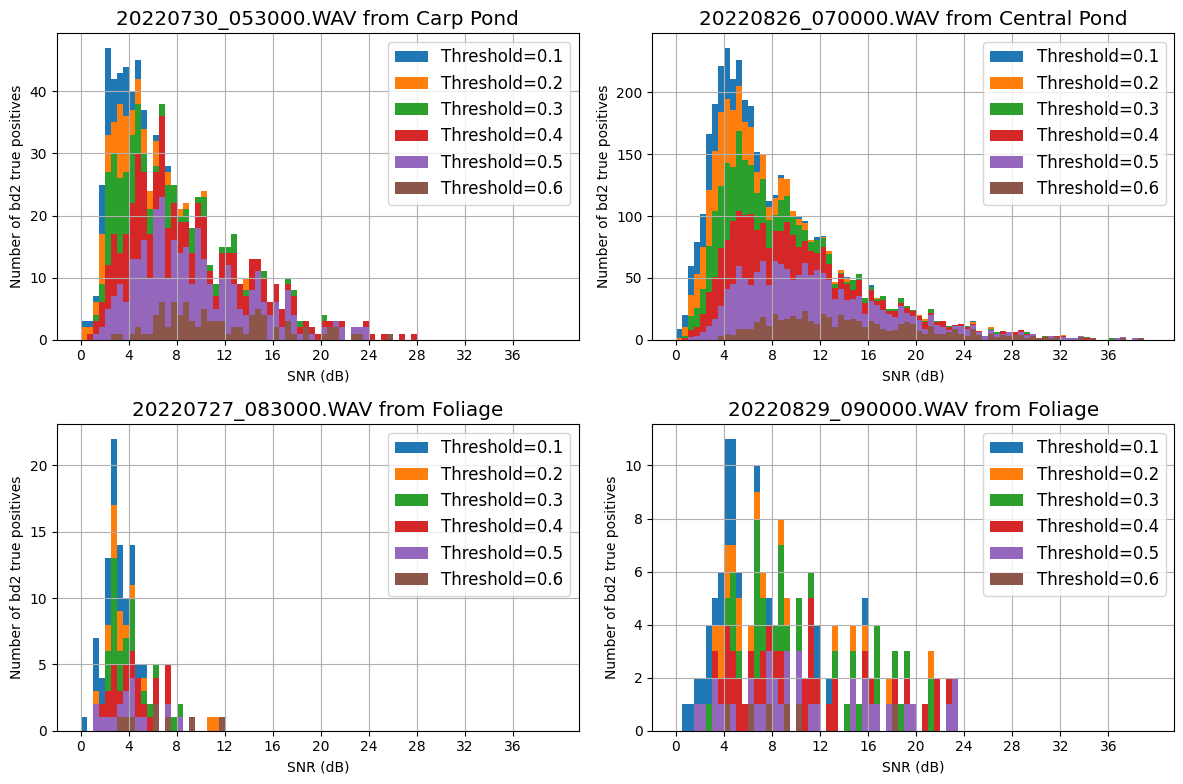

In [16]:
fig, ax = plt.subplots(2,2,figsize=(12,8))
plt.rcParams.update({'font.size':12})
easy_ax = ax.flatten()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")
    filepath = bd2_dets_save_dir / save_loc
    batdetect2_df_file = pd.read_csv(filepath, sep=',', index_col=0)
    batdetect2_df_file.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

    increment = 0.1
    detection_thresholds = np.arange(0.1, 0.6+increment, increment)
    for det_thresh in detection_thresholds:
        det_thresh = round(det_thresh, 2)
        batdetect2_df_detthresh = batdetect2_df_file[batdetect2_df_file['det_prob']>=det_thresh].copy().reset_index()
        true_positives_batdetect2_df_detthresh, true_positives = return_true_positives_using_human_df(bd2_human_df_file, batdetect2_df_detthresh)

        true_positives_batdetect2_df_detthresh['SNR'].hist(bins=np.arange(0, 40, 0.5), label=f'Threshold={det_thresh}',
                                            ax=easy_ax[file_num])
        easy_ax[file_num].set_title(f'{file_key}.WAV from {SITE_NAMES[site]}')
        easy_ax[file_num].set_xticks(np.arange(0, 40, 4))
        easy_ax[file_num].set_xlabel('SNR (dB)')
        easy_ax[file_num].set_ylabel('Number of bd2 true positives')
        easy_ax[file_num].legend()

fig.tight_layout()
plt.show()

In [ ]:
all_files_batdetct2_df_true_positives = pd.DataFrame()
all_files_batdetct2_df = pd.DataFrame()
# for file_num, file_key in enumerate(file_keys):
file_key = '20220826_070000'
wav_filename = file_key
site = file_sites[file_key]
plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")
filepath = bd2_dets_save_dir / save_loc
batdetect2_df_file = pd.read_csv(filepath, sep=',', index_col=0)
batdetect2_df_file.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, batdetect2_df_file])

true_positives_batdetect2_df_file, true_positives = return_true_positives_using_human_df(bd2_human_df_file, batdetect2_df_file)
# all_files_batdetct2_df_true_positives = pd.concat([all_files_batdetct2_df_true_positives, true_positives_batdetect2_df_file])

In [49]:
all_files_batdetct2_df_true_positives = pd.DataFrame()
all_files_batdetct2_df = pd.DataFrame()
for file_num, file_key in enumerate(file_keys):
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file.reset_index(drop=True)

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")
    filepath = bd2_dets_save_dir / save_loc
    batdetect2_df_file = pd.read_csv(filepath, sep=',', index_col=0)
    batdetect2_df_file.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, batdetect2_df_file])

    true_positives_batdetect2_df_file, true_positives = return_true_positives_using_human_df(bd2_human_df_file, batdetect2_df_file, debug=False)
    all_files_batdetct2_df_true_positives = pd.concat([all_files_batdetct2_df_true_positives, true_positives_batdetect2_df_file])

HI:0 start:230.809010623, MI:0 SEL:1 start:0.0015, TP:0, FP:0, FN:0, TN:0
Dets match time: False, Dets match freq: True
FP same group: True, FP diff group: False
FN same group: False, FN diff group: False
HI:0 start:230.809010623, MI:1 SEL:2 start:0.0015, TP:0, FP:1, FN:0, TN:0
Dets match time: False, Dets match freq: False
FP same group: False, FP diff group: True
FN same group: False, FN diff group: False
HI:0 start:230.809010623, MI:2 SEL:3 start:0.0275, TP:0, FP:2, FN:0, TN:0
Dets match time: False, Dets match freq: False
FP same group: False, FP diff group: True
FN same group: False, FN diff group: False
HI:0 start:230.809010623, MI:3 SEL:4 start:0.1255, TP:0, FP:3, FN:0, TN:0
Dets match time: False, Dets match freq: False
FP same group: False, FP diff group: True
FN same group: False, FN diff group: False
HI:0 start:230.809010623, MI:4 SEL:5 start:0.1845, TP:0, FP:4, FN:0, TN:0
Dets match time: False, Dets match freq: False
FP same group: False, FP diff group: True
FN same group:

KeyboardInterrupt: 

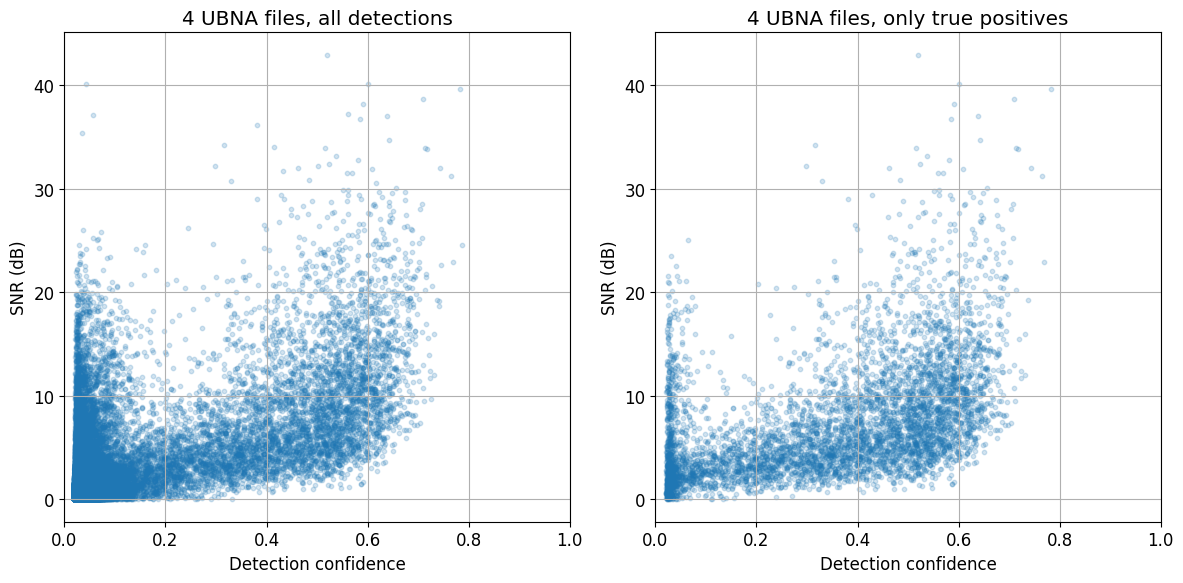

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.set_title(f'4 UBNA files, all detections')
ax1.scatter(all_files_batdetct2_df['det_prob'].values, all_files_batdetct2_df['SNR'].values,
            alpha=0.2, s=10)
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)

ax2.set_title(f'4 UBNA files, only true positives')
ax2.scatter(all_files_batdetct2_df_true_positives['det_prob'].values, all_files_batdetct2_df_true_positives['SNR'].values,
            alpha=0.2, s=10)
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)

fig.tight_layout()
plt.show()

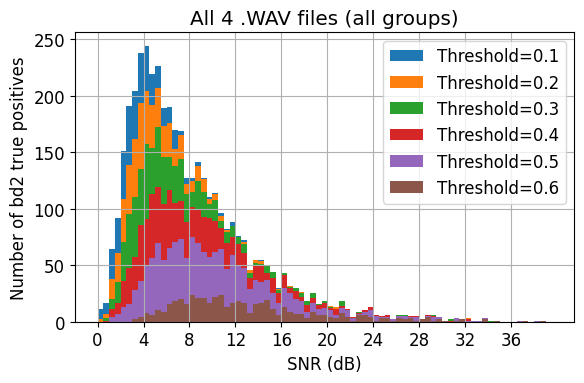

In [19]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':12})
increment = 0.1
detection_thresholds = np.arange(0.1, 0.6+increment, increment)
for det_thresh in detection_thresholds:
    det_thresh = round(det_thresh, 2)
    batdetect2_df_detthresh = all_files_batdetct2_df_true_positives[all_files_batdetct2_df_true_positives['det_prob']>=det_thresh].copy().reset_index()

    batdetect2_df_detthresh['SNR'].hist(bins=np.arange(0, 40, 0.5), label=f'Threshold={det_thresh}',ax=ax)
    ax.set_title(f'All 4 .WAV files (all groups)')
    ax.set_xticks(np.arange(0, 40, 4))
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Number of bd2 true positives')
    ax.legend()

fig.tight_layout()
plt.show()

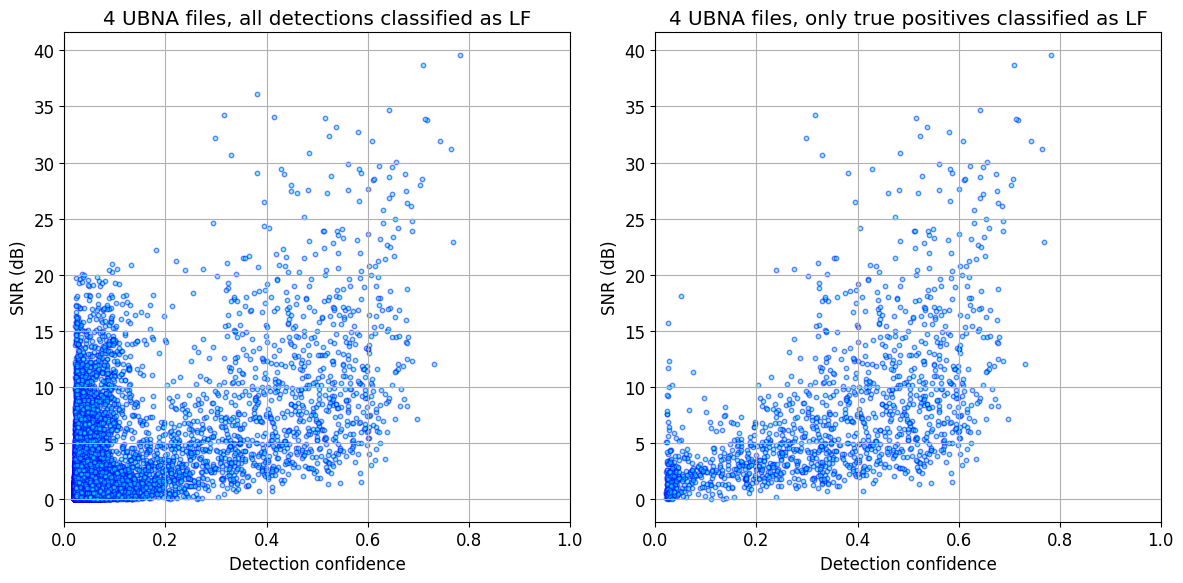

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.set_title(f'4 UBNA files, all detections classified as LF')
lf_all_files_batdetct2_df = all_files_batdetct2_df[all_files_batdetct2_df['freq_group']=='LF']
ax1.scatter(lf_all_files_batdetct2_df['det_prob'].values, lf_all_files_batdetct2_df['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)

ax2.set_title(f'4 UBNA files, only true positives classified as LF')
lf_all_files_batdetct2_df_true_positives = all_files_batdetct2_df_true_positives[all_files_batdetct2_df_true_positives['freq_group']=='LF']
ax2.scatter(lf_all_files_batdetct2_df_true_positives['det_prob'].values, lf_all_files_batdetct2_df_true_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)

fig.tight_layout()
plt.show()

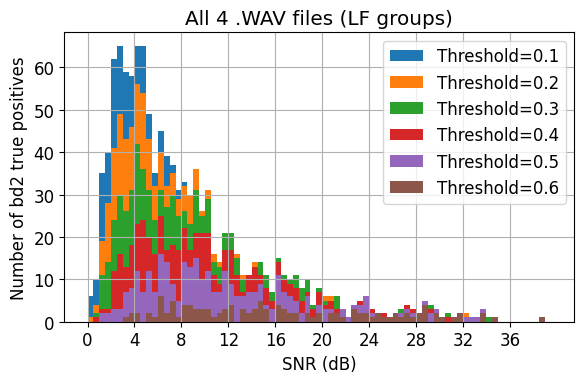

In [21]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':12})
increment = 0.1
lf_all_files_batdetct2_df = all_files_batdetct2_df_true_positives[all_files_batdetct2_df_true_positives['freq_group']=='LF']
detection_thresholds = np.arange(0.1, 0.6+increment, increment)
for det_thresh in detection_thresholds:
    det_thresh = round(det_thresh, 2)
    batdetect2_df_detthresh = lf_all_files_batdetct2_df[lf_all_files_batdetct2_df['det_prob']>=det_thresh].copy().reset_index()

    batdetect2_df_detthresh['SNR'].hist(bins=np.arange(0, 40, 0.5), label=f'Threshold={det_thresh}',ax=ax)
    ax.set_title(f'All 4 .WAV files (LF groups)')
    ax.set_xticks(np.arange(0, 40, 4))
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Number of bd2 true positives')
    ax.legend()

fig.tight_layout()
plt.show()

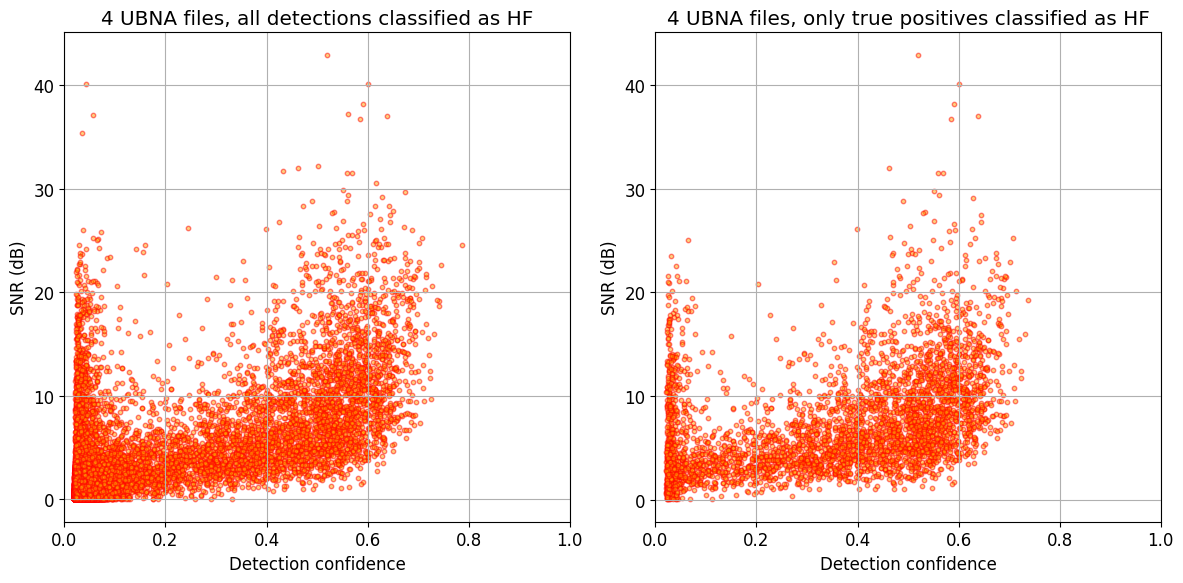

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.set_title(f'4 UBNA files, all detections classified as HF')
hf_all_files_batdetct2_df = all_files_batdetct2_df[all_files_batdetct2_df['freq_group']=='HF']
ax1.scatter(hf_all_files_batdetct2_df['det_prob'].values, hf_all_files_batdetct2_df['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax1.grid(which='both')
ax1.set_xlabel('Detection confidence')
ax1.set_ylabel('SNR (dB)')
ax1.set_xlim(0, 1.0)

ax2.set_title(f'4 UBNA files, only true positives classified as HF')
hf_all_files_batdetct2_df_true_positives = all_files_batdetct2_df_true_positives[all_files_batdetct2_df_true_positives['freq_group']=='HF']
ax2.scatter(hf_all_files_batdetct2_df_true_positives['det_prob'].values, hf_all_files_batdetct2_df_true_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='orange', edgecolor='red')
ax2.grid(which='both')
ax2.set_xlabel('Detection confidence')
ax2.set_ylabel('SNR (dB)')
ax2.set_xlim(0, 1.0)

fig.tight_layout()
plt.show()

In [31]:
SNR_thresh = 0
detprobthresh = 0.1
sample_df = all_files_batdetct2_df[(all_files_batdetct2_df['det_prob']<=detprobthresh)&(all_files_batdetct2_df['SNR']>=SNR_thresh)]
sample_df_true_positives = all_files_batdetct2_df_true_positives[(all_files_batdetct2_df_true_positives['det_prob']<=detprobthresh)&(all_files_batdetct2_df_true_positives['SNR']>=SNR_thresh)]

In [32]:
sample_df_file = sample_df[pd.to_datetime(sample_df['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False)==dt.datetime(2022,8,26,7,0,0)].reset_index(drop=True)
sample_df_file_true_positives = sample_df_true_positives[pd.to_datetime(sample_df_true_positives['input_file'], format='%Y%m%d_%H%M%S.WAV', exact=False)==dt.datetime(2022,8,26,7,0,0)].reset_index(drop=True)

In [33]:
sep = "\t"
sample_ravenpro_df = convert_bd2df_ravenpro(sample_df_file)
sample_ravenpro_df_true_positives = convert_bd2df_ravenpro(sample_df_file_true_positives)

In [34]:
sample_ravenpro_df

,Manually-Verified Phonic Group,peak_frequency,SNR,Begin Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),class,class_prob,det_prob,individual,Annotation,sampling_rate,input_file,Selection,View,Channel
0,HF,70080.0,0.844350,0.0015,0.0328,68437,79536,Rhinolophus ferrumequinum,0.028,0.028,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,1,Waveform 1,1
1,HF,48960.0,1.866691,0.0015,0.0099,47812,51961,Pipistrellus pipistrellus,0.029,0.035,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,2,Waveform 1,1
2,LF,22080.0,1.049929,0.0015,0.0096,22890,29153,Nyctalus leisleri,0.012,0.032,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,3,Waveform 1,1
3,LF,22080.0,4.325132,0.0685,0.0827,22890,27157,Nyctalus leisleri,0.015,0.026,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,4,Waveform 1,1
4,HF,20160.0,5.142153,0.0725,0.0786,11718,63812,Myotis bechsteinii,0.009,0.025,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,5,Waveform 1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86458,LF,24960.0,0.107389,1794.9225,1794.9321,24609,33274,Eptesicus serotinus,0.008,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,86459,Waveform 1,1
86459,LF,24960.0,0.340875,1794.9315,1794.9378,25468,40579,Plecotus austriacus,0.005,0.024,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,86460,Waveform 1,1
86460,HF,78720.0,0.272522,1794.9455,1794.9826,68437,81974,Rhinolophus ferrumequinum,0.023,0.023,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,86461,Waveform 1,1
86461,LF,22080.0,1.793079,1794.9505,1794.9610,22031,27451,Nyctalus leisleri,0.011,0.031,-1,Echolocation,192000,/home/adkris/Documents/mila-human-wav-txt/2022...,86462,Waveform 1,1


In [37]:
ones = int(detprobthresh)
decimals = int(int(100*(detprobthresh)) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
threshold_tag

'threshold0p10'

In [42]:
sample_ravenpro_df.to_csv(f'20250113__20220826_070000_sample_ravenpro_df_all_detections_detprob{threshold_tag}_SNRthresh{SNR_thresh}.txt', sep=sep, index=False)
sample_ravenpro_df_true_positives.to_csv(f'20250113__20220826_070000_sample_ravenpro_df_true_positives_detprob{threshold_tag}_SNRthresh{SNR_thresh}.txt', sep=sep, index=False)

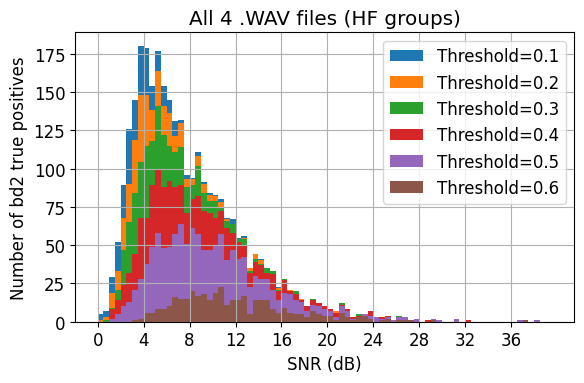

In [33]:
fig, ax = plt.subplots(1,1,figsize=(6,4))
plt.rcParams.update({'font.size':12})
increment = 0.1
hf_all_files_batdetct2_df = all_files_batdetct2_df_true_positives[all_files_batdetct2_df_true_positives['freq_group']=='HF']
detection_thresholds = np.arange(0.1, 0.6+increment, increment)
for det_thresh in detection_thresholds:
    det_thresh = round(det_thresh, 2)
    batdetect2_df_detthresh = hf_all_files_batdetct2_df[hf_all_files_batdetct2_df['det_prob']>=det_thresh].copy().reset_index()

    batdetect2_df_detthresh['SNR'].hist(bins=np.arange(0, 40, 0.5), label=f'Threshold={det_thresh}',ax=ax)
    ax.set_title(f'All 4 .WAV files (HF groups)')
    ax.set_xticks(np.arange(0, 40, 4))
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Number of bd2 true positives')
    ax.legend()

fig.tight_layout()
plt.show()

In [29]:
batdetect2_eval = pd.DataFrame()
batdetect2_eval_LF = pd.DataFrame()
batdetect2_eval_HF = pd.DataFrame()
for file_key in file_keys:
    wav_filename = file_key
    site = file_sites[file_key]
    plot_file = Path(f'{raventxt_human_files_dir}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{raventxt_human_files_dir}/{raventxt_human_filename}_ravenpro_SNR_and_aditya_SNR.txt', sep=sep)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}.csv")
    filepath = bd2_dets_save_dir / save_loc
    batdetect2_df_file = pd.read_csv(filepath, sep=',', index_col=0)
    batdetect2_df_file.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)

    batdetect2_eval_file = generate_evaluation_df(bd2_human_df_file, batdetect2_df_file)
    batdetect2_eval_file['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file)
    batdetect2_eval_file['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file)

    bd2_human_df_file_LF = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].copy()
    batdetect2_df_file_LF = batdetect2_df_file[batdetect2_df_file['freq_group']=='LF'].copy()
    batdetect2_eval_file_LF = generate_evaluation_df(bd2_human_df_file_LF, batdetect2_df_file_LF)
    batdetect2_eval_file_LF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_LF)
    batdetect2_eval_file_LF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_LF)

    bd2_human_df_file_HF = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].copy()
    batdetect2_df_file_HF = batdetect2_df_file[batdetect2_df_file['freq_group']=='HF'].copy()
    batdetect2_eval_file_HF = generate_evaluation_df(bd2_human_df_file_HF, batdetect2_df_file_HF)
    batdetect2_eval_file_HF['input_file_name'] = [f'{wav_filename}.WAV']*len(batdetect2_eval_file_HF)
    batdetect2_eval_file_HF['site_name'] = [SITE_NAMES[site]]*len(batdetect2_eval_file_HF)

    batdetect2_eval = pd.concat([batdetect2_eval, batdetect2_eval_file])
    batdetect2_eval_LF = pd.concat([batdetect2_eval_LF, batdetect2_eval_file_LF])
    batdetect2_eval_HF = pd.concat([batdetect2_eval_HF, batdetect2_eval_file_HF])

0.0 0.05
0.0 0.06
0.0 0.07
0.0 0.08


0.0 0.09
0.0 0.1
0.0 0.11
0.0 0.12
0.0 0.13
0.0 0.14
0.0 0.15
0.0 0.16
0.0 0.17
0.0 0.18
0.0 0.19
0.0 0.2
0.0 0.21
0.0 0.22
0.0 0.23
0.0 0.24
0.0 0.25
0.0 0.26
0.0 0.27
0.0 0.28
0.0 0.29
0.0 0.3
0.0 0.31
0.0 0.32
0.0 0.33
0.0 0.34
0.0 0.35
0.0 0.36
0.0 0.37
0.0 0.38
0.0 0.39
0.0 0.4
0.0 0.41
0.0 0.42
0.0 0.43
0.0 0.44
0.0 0.45
0.0 0.46
0.0 0.47
0.0 0.48
0.0 0.49
0.0 0.5
0.0 0.51
0.0 0.52
0.0 0.53
0.0 0.54
0.0 0.55
0.0 0.56
0.0 0.57
0.0 0.58
0.0 0.59
0.0 0.6
2.0 0.05
2.0 0.06
2.0 0.07
2.0 0.08
2.0 0.09
2.0 0.1
2.0 0.11
2.0 0.12
2.0 0.13
2.0 0.14
2.0 0.15
2.0 0.16
2.0 0.17
2.0 0.18
2.0 0.19
2.0 0.2
2.0 0.21
2.0 0.22
2.0 0.23
2.0 0.24
2.0 0.25
2.0 0.26
2.0 0.27
2.0 0.28
2.0 0.29
2.0 0.3
2.0 0.31
2.0 0.32
2.0 0.33
2.0 0.34
2.0 0.35
2.0 0.36
2.0 0.37
2.0 0.38
2.0 0.39
2.0 0.4
2.0 0.41
2.0 0.42
2.0 0.43
2.0 0.44
2.0 0.45
2.0 0.46
2.0 0.47
2.0 0.48
2.0 0.49
2.0 0.5
2.0 0.51
2.0 0.52
2.0 0.53
2.0 0.54
2.0 0.55
2.0 0.56
2.0 0.57
2.0 0.58
2.0 0.59
2.0 0.6
4.0 0.05
4.0 0.06
4.0 0.07
4.0 0.08
4.0 

KeyboardInterrupt: 

In [103]:
batdetect2_eval.to_csv(bd2_dets_save_dir / '20250101__bd2_eval_results_per_thresh_and_file.csv')
batdetect2_eval_LF.to_csv(bd2_dets_save_dir / '20250101__bd2_LFeval_results_per_thresh_and_file.csv')
batdetect2_eval_HF.to_csv(bd2_dets_save_dir / '20250101__bd2_HFeval_results_per_thresh_and_file.csv')